<a href="https://colab.research.google.com/github/NadineAppiah/lab-2-predictive-analytics/blob/main/lab_2_predictive_analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
RANDOM_STATE = 42

TAXI_URL    = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/pu9kbeSaAtRZ7RxdJKX9_A/yellow-tripdata.csv"
OBESITY_URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/GkDzb7bWrtvGXdPOfk6CIg/Obesity-level-prediction-dataset.csv"

(41202, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41202 entries, 0 to 41201
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   VendorID               41202 non-null  int64  
 1   passenger_count        41202 non-null  int64  
 2   trip_distance          41202 non-null  float64
 3   RatecodeID             41202 non-null  int64  
 4   store_and_fwd_flag     41202 non-null  int64  
 5   PULocationID           41202 non-null  int64  
 6   DOLocationID           41202 non-null  int64  
 7   payment_type           41202 non-null  int64  
 8   fare_amount            41202 non-null  float64
 9   mta_tax                41202 non-null  float64
 10  tolls_amount           41202 non-null  float64
 11  improvement_surcharge  41202 non-null  int64  
 12  tip_amount             41202 non-null  float64
dtypes: float64(5), int64(8)
memory usage: 4.1 MB


,VendorID,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,mta_tax,tolls_amount,improvement_surcharge,tip_amount
count,41202.0,41202.000000,41202.000000,41202.000000,41202.000000,41202.000000,41202.000000,41202.0,41202.000000,41202.000000,41202.000000,41202.000000,41202.000000
mean,2.0,1.633926,18.384928,2.025411,0.999393,132.220475,164.546333,1.0,69.986150,0.491020,5.608198,0.999976,14.107666
std,0.0,0.924250,2.856605,0.461587,0.024625,7.726159,67.901529,0.0,6.184851,0.066404,2.979348,0.004927,5.030619
min,2.0,1.000000,0.000000,1.000000,0.000000,10.000000,3.000000,1.0,3.700000,0.000000,0.000000,0.000000,0.010000
25%,2.0,1.000000,17.370000,2.000000,1.000000,132.000000,113.000000,1.0,70.000000,0.500000,6.940000,1.000000,10.000000
50%,2.0,1.000000,18.180000,2.000000,1.000000,132.000000,163.000000,1.0,70.000000,0.500000,6.940000,1.000000,16.190000
75%,2.0,2.000000,19.380000,2.000000,1.000000,132.000000,231.000000,1.0,70.000000,0.500000,6.940000,1.000000,16.190000
max,2.0,8.000000,189.910000,5.000000,1.000000,264.000000,265.000000,1.0,199.700000,0.500000,57.000000,1.000000,98.000000


,0
VendorID,0
passenger_count,0
trip_distance,0
RatecodeID,0
store_and_fwd_flag,0
PULocationID,0
DOLocationID,0
payment_type,0
fare_amount,0
mta_tax,0


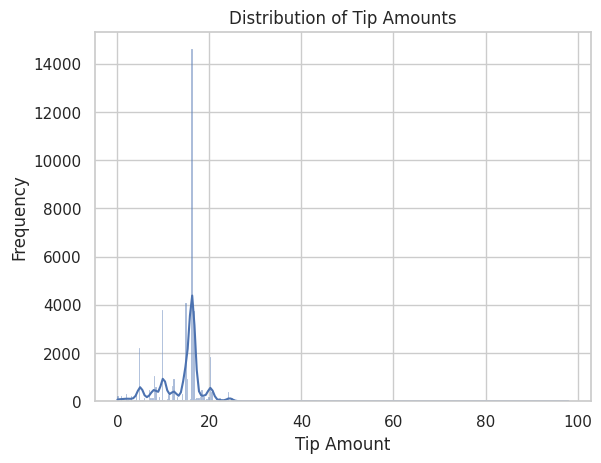

In [24]:
taxi = pd.read_csv(TAXI_URL)

print(taxi.shape)
taxi.head()
taxi.info()
display(taxi.describe())
display(taxi.isna().sum())

sns.histplot(taxi['tip_amount'], kde=True)
plt.title('Distribution of Tip Amounts')
plt.xlabel('Tip Amount')
plt.ylabel('Frequency')
plt.show()


**Taxi data exploration**

Shape is 41202 rows and 13 columns(41202*13), no missing values. There are zero-distance trips. tip_amount is right-skewed around $15-20, a smaller group of lower tips around$0-10.
Drop or fix zero-distance rows, constant columns before engineering a fare-per-mile feature.  

In [25]:
taxi = taxi.dropna()
taxi = taxi[taxi['trip_distance'] > 0]
taxi = taxi[taxi['fare_amount'] > 0]
taxi = taxi[taxi['tip_amount'] >= 0]
print(taxi.shape)

taxi['fare_per_mile'] = taxi['fare_amount'] / taxi['trip_distance']
taxi['total_surcharges'] = taxi['mta_tax']+taxi['tolls_amount']+taxi['improvement_surcharge']
taxi.head()

categorical_cols = ['VendorID','RatecodeID','payment_type','store_and_fwd_flag']
numerical_cols   = ['trip_distance','fare_amount','total_surcharges','fare_per_mile']

taxi = pd.get_dummies(taxi, columns=categorical_cols, drop_first=True)
taxi.head()



(41126, 13)


,passenger_count,trip_distance,PULocationID,DOLocationID,fare_amount,mta_tax,tolls_amount,improvement_surcharge,tip_amount,fare_per_mile,total_surcharges,RatecodeID_2,RatecodeID_4,RatecodeID_5,store_and_fwd_flag_1
0,1,17.63,132,164,70.0,0.5,6.94,1,16.54,3.970505,8.44,True,False,False,True
1,1,19.52,132,236,70.0,0.5,6.94,1,16.19,3.586066,8.44,True,False,False,True
2,1,17.81,132,48,70.0,0.5,6.94,1,12.00,3.930376,8.44,True,False,False,True
3,2,19.30,132,148,70.0,0.5,0.00,1,5.00,3.626943,1.50,True,False,False,True
4,1,18.75,132,234,70.0,0.5,6.94,1,10.00,3.733333,8.44,True,False,False,True


**Taxi preprocessing**

1. I removed rows with invalid values such as trip_distance <= 0 and fare_amount <= 0.
2. I created fare_per_mile and total_subcharges to get trip cost characteristics that may influence tipping.
3. StandardScaler because the numeric features were on different scales.

In [26]:
x = taxi.drop('tip_amount', axis=1)
y = taxi['tip_amount']

from sklearn.model_selection import train_test_split
x_temp, x_test, y_temp, y_test = train_test_split(x, y, test_size=0.2, random_state=RANDOM_STATE)
x_train, x_val, y_train, y_val = train_test_split(x_temp, y_temp, test_size=0.25, random_state=RANDOM_STATE)

print(x_train.shape, x_val.shape, x_test.shape)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train[numerical_cols] = scaler.fit_transform(x_train[numerical_cols])
x_val[numerical_cols]   = scaler.transform(x_val[numerical_cols])
x_test[numerical_cols]  = scaler.transform(x_test[numerical_cols])


(24675, 14) (8225, 14) (8226, 14)


**Splitting**

I used a 60/20/20 train-validation-test split. The validation set was used for model selection, and the test set was reserved for the final evaluation. The scaler is fit only on the training data to prevent data leakage.

Train(Linear): RMSE = 4.8045, R² = 0.0513
Validate(Linear): RMSE = 5.0371, R² = 0.0486
Test(Linear): RMSE = 5.0132, R² = 0.0511
Train(RFR): RMSE = 2.8362, R² = 0.6694
Validate(RFR): RMSE = 5.6462, R² = -0.1953
Test(RFR): RMSE = 5.6097, R² = -0.1882


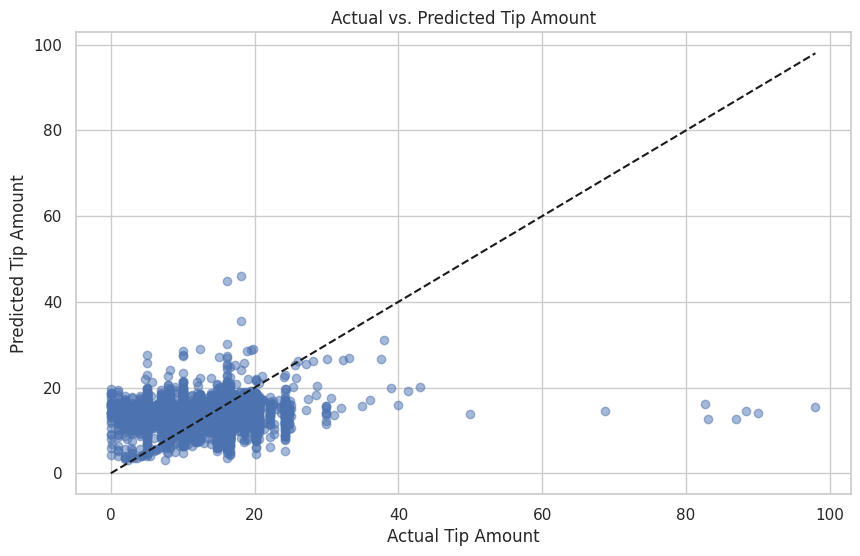

In [16]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

linear_reg = LinearRegression()
linear_reg.fit(x_train, y_train)

y_train_pred = linear_reg.predict(x_train)
y_val_pred = linear_reg.predict(x_val)
y_test_pred = linear_reg.predict(x_test)

def report_metrics(y_true, y_pred, label):
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    r2 = r2_score(y_true, y_pred)
    print(f"{label}: RMSE = {rmse:.4f}, R² = {r2:.4f}")

report_metrics(y_train, y_train_pred, 'Train(Linear)')
report_metrics(y_val, y_val_pred, 'Validate(Linear)')
report_metrics(y_test, y_test_pred, 'Test(Linear)')

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

rfreg = RandomForestRegressor(random_state=RANDOM_STATE)
rfreg.fit(x_train, y_train)

y_train_pred = rfreg.predict(x_train)
y_val_pred = rfreg.predict(x_val)
y_test_pred = rfreg.predict(x_test)

report_metrics(y_train, y_train_pred, 'Train(RFR)')
report_metrics(y_val, y_val_pred, 'Validate(RFR)')
report_metrics(y_test, y_test_pred, 'Test(RFR)')

import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_test_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--')
plt.xlabel('Actual Tip Amount')
plt.ylabel('Predicted Tip Amount')
plt.title('Actual vs. Predicted Tip Amount')
plt.show()

**Regression Evaluation and Overfitting**

1. Linear Regression performed best on the validation set(RMSE = 5.0371, R² = 0.0486). I compared it with RandomForestRegressor.
2. LinearRegression is well-fitted because train, validation and test score were similar (R²≈ 0.05). RandomForestRegression overfit(Train(RFR): R² = 0.6694 and Test(RFR):R² = -0.1882).
3. To reduce overfitting I would limit tree depth.

(2111, 17)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   object 
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   object 
 5   FAVC                            2111 non-null   object 
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   object 
 9   SMOKE                           2111 non-null   object 
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   object 
 12  FAF                    

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000
mean,24.312600,1.701677,86.586058,2.419043,2.685628,2.008011,1.010298,0.657866
std,6.345968,0.093305,26.191172,0.533927,0.778039,0.612953,0.850592,0.608927
min,14.000000,1.450000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,19.947192,1.630000,65.473343,2.000000,2.658738,1.584812,0.124505,0.000000
50%,22.777890,1.700499,83.000000,2.385502,3.000000,2.000000,1.000000,0.625350
75%,26.000000,1.768464,107.430682,3.000000,3.000000,2.477420,1.666678,1.000000
max,61.000000,1.980000,173.000000,3.000000,4.000000,3.000000,3.000000,2.000000


,0
Gender,0
Age,0
Height,0
Weight,0
family_history_with_overweight,0
FAVC,0
FCVC,0
NCP,0
CAEC,0
SMOKE,0


NObeyesdad
Obesity_Type_I         351
Obesity_Type_III       324
Obesity_Type_II        297
Overweight_Level_I     290
Overweight_Level_II    290
Normal_Weight          287
Insufficient_Weight    272
Name: count, dtype: int64


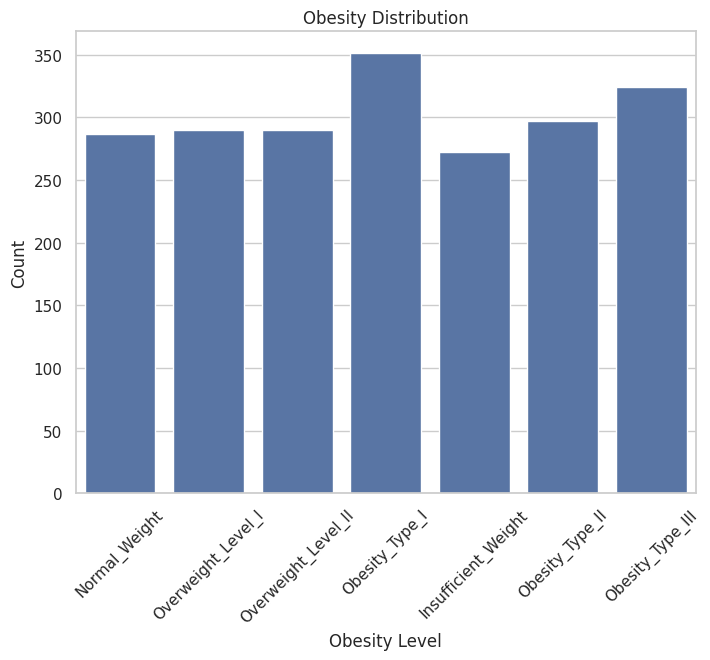

In [17]:
obesity = pd.read_csv(OBESITY_URL)
print(obesity.shape)
obesity.head()
obesity.info()
display(obesity.describe())
display(obesity.isna().sum())

print(obesity['NObeyesdad'].value_counts())

import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6))
sns.countplot(x='NObeyesdad', data=obesity)
plt.xticks(rotation=45)
plt.title('Obesity Distribution')
plt.xlabel('Obesity Level')
plt.ylabel('Count')
plt.show()


**Obesity data exploration**

The dataset has numerical and categorical features.
Numerical features include age, height, weight.
Categorical features include gender, MTRANS, CAEC, CALC.
Yes, the target is fairly balanced across the 7 classes.
Class balance matters because imbalanced classes can bias the classifier toward majority classes.

In [18]:
binary_cols = ['family_history_with_overweight','FAVC','SMOKE','SCC']

for col in binary_cols:
    obesity[col] = obesity[col].map({'yes': 1, 'no': 0})

from sklearn.preprocessing import OrdinalEncoder
caec_order = ['no', 'Sometimes', 'Frequently', 'Always']
calc_order = ['no', 'Sometimes', 'Frequently', 'Always']
ord_encoder = OrdinalEncoder(categories=[caec_order, calc_order])
obesity[['CAEC', 'CALC']] = ord_encoder.fit_transform(obesity[['CAEC', 'CALC']])

obesity = pd.get_dummies(obesity, columns=['Gender','MTRANS'], drop_first=True)

obesity['BMI'] = obesity['Weight'] / (obesity['Height']) ** 2

from sklearn.preprocessing import LabelEncoder
target_encoder = LabelEncoder()
obesity['NObeyesdad'] = target_encoder.fit_transform(obesity['NObeyesdad'])
print(dict(zip(target_encoder.classes_, target_encoder.transform(target_encoder.classes_))))


{'Insufficient_Weight': np.int64(0), 'Normal_Weight': np.int64(1), 'Obesity_Type_I': np.int64(2), 'Obesity_Type_II': np.int64(3), 'Obesity_Type_III': np.int64(4), 'Overweight_Level_I': np.int64(5), 'Overweight_Level_II': np.int64(6)}


**Obesity preprocessing**

1. Binary variables were encoded as 0/1, and nominal variables were one-hot encoded.
2. I engineered BMI = weight/height **2, which is related to the obesity level and does not leak the target.
3. I used StandardScaler to ensure all numerical features were on a comparable scale.

In [19]:
x = obesity.drop('NObeyesdad', axis=1)
y = obesity['NObeyesdad']

from sklearn.model_selection import train_test_split

x_temp, x_test, y_temp, y_test = train_test_split(x, y, test_size=0.2, stratify = y, random_state=RANDOM_STATE)

x_train, x_val, y_train, y_val = train_test_split(x_temp, y_temp, test_size=0.25, stratify = y_temp, random_state=RANDOM_STATE)

print(x_train.shape, x_val.shape, x_test.shape)

numerical_cols = ['Age', 'Weight', 'Height', 'FCVC','NCP','CH2O','FAF','TUE','BMI']
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train[numerical_cols] = scaler.fit_transform(x_train[numerical_cols])
x_val[numerical_cols]   = scaler.transform(x_val[numerical_cols])
x_test[numerical_cols]  = scaler.transform(x_test[numerical_cols])

print(y_train.value_counts(normalize=True).sort_index())
print(y_val.value_counts(normalize=True).sort_index())
print(y_test.value_counts(normalize=True).sort_index())


(1266, 20) (422, 20) (423, 20)
NObeyesdad
0    0.128752
1    0.135861
2    0.166667
3    0.140600
4    0.153239
5    0.137441
6    0.137441
Name: proportion, dtype: float64
NObeyesdad
0    0.130332
1    0.135071
2    0.165877
3    0.139810
4    0.154028
5    0.137441
6    0.137441
Name: proportion, dtype: float64
NObeyesdad
0    0.127660
1    0.137116
2    0.165485
3    0.141844
4    0.153664
5    0.137116
6    0.137116
Name: proportion, dtype: float64


**Splitting**

I used 60/20/20 split. Stratification is important because it preserves the class proportions across all the datasets. Without stratifying, some obesity classes could be missing in a split.

              precision    recall  f1-score   support

           0       0.93      0.99      0.96       163
           1       0.92      0.85      0.88       172
           2       0.97      0.95      0.96       211
           3       0.97      0.99      0.98       178
           4       1.00      1.00      1.00       194
           5       0.84      0.83      0.84       174
           6       0.85      0.87      0.86       174

    accuracy                           0.93      1266
   macro avg       0.93      0.93      0.93      1266
weighted avg       0.93      0.93      0.93      1266

              precision    recall  f1-score   support

           0       0.86      1.00      0.92        55
           1       0.97      0.63      0.77        57
           2       0.96      0.94      0.95        70
           3       0.97      1.00      0.98        59
           4       1.00      1.00      1.00        65
           5       0.69      0.83      0.75        58
           6       0.79 

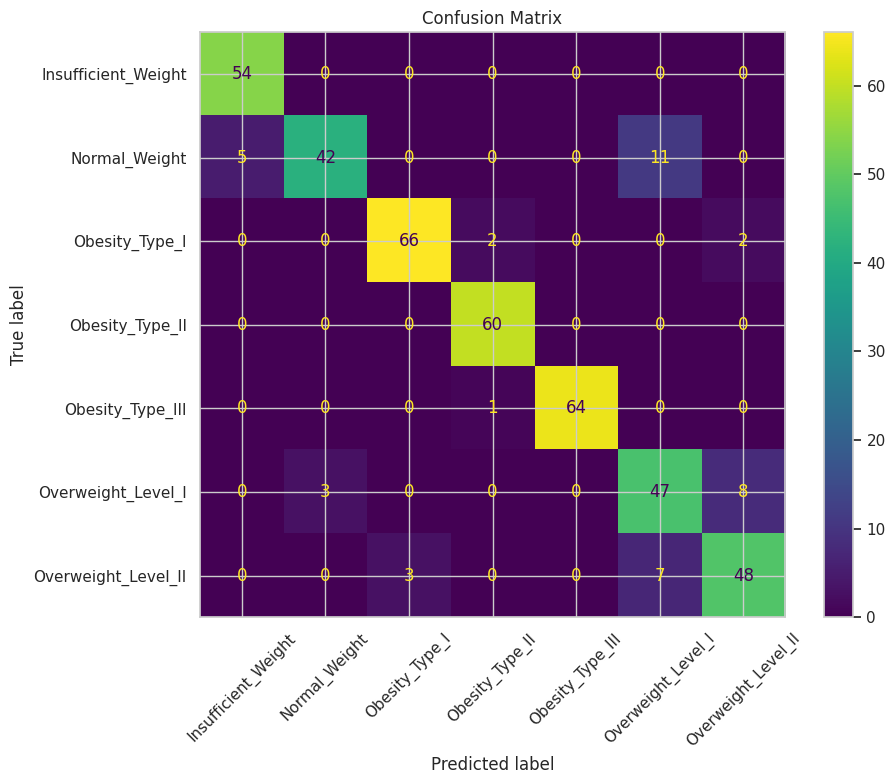

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(x_train, y_train)

y_train_pred = log_reg.predict(x_train)
y_val_pred = log_reg.predict(x_val)
y_test_pred = log_reg.predict(x_test)

from sklearn.metrics import accuracy_score, f1_score, classification_report

def report_metrics(y_true, y_pred, label):
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    print(f"{label}:")
    print(f"Accuracy: {accuracy_score(y_true, y_pred):.4f}")

print(classification_report(y_train, y_train_pred))
print(classification_report(y_val, y_val_pred))
print(classification_report(y_test, y_test_pred))

from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize = (10,8))
ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred, ax=ax,
                        display_labels=target_encoder.classes_,
                                        xticks_rotation=45)
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()



**Classification evaluation and overfitting**

1. I used LogisticRegression because it is useful for multiclass classification.
2. The model was well-fitted
Train Accuracy/F1 = 0.93/0.93, Validation Accuracy/F1 = 0.88, Test Accuracy/F1 = 0.90/0.90.
3. The Overweight_Level_I and Overweight_Level_II are commonly confused because they have similar characteristics.


(2111, 20)


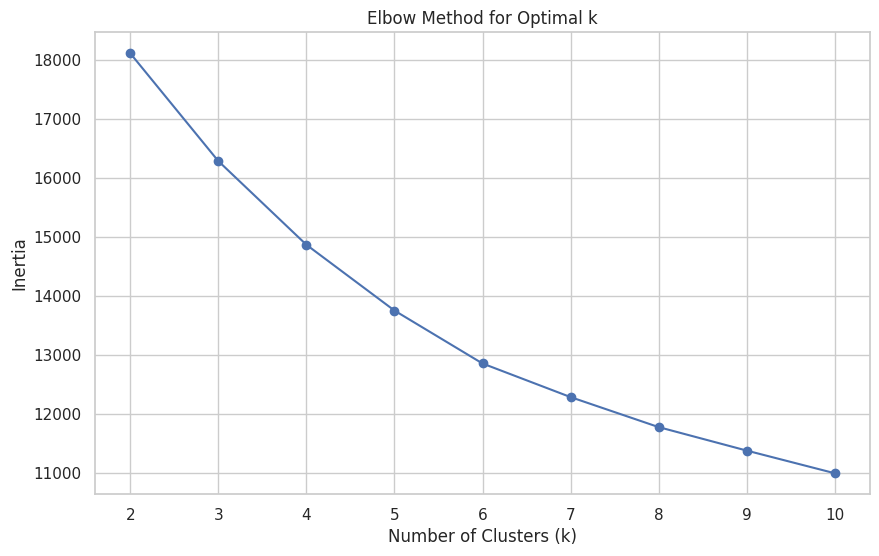

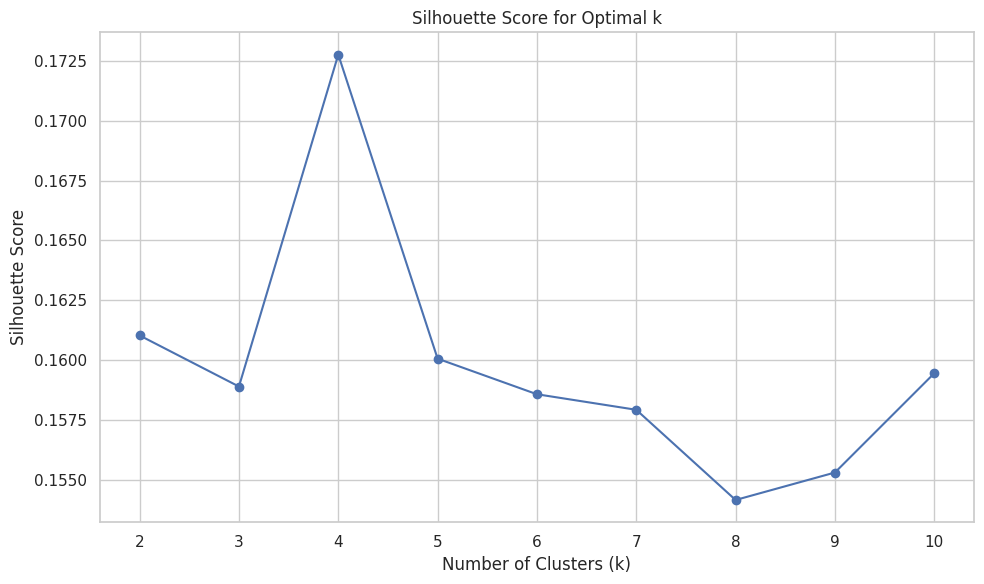

[0 1 1 ... 6 0 5]


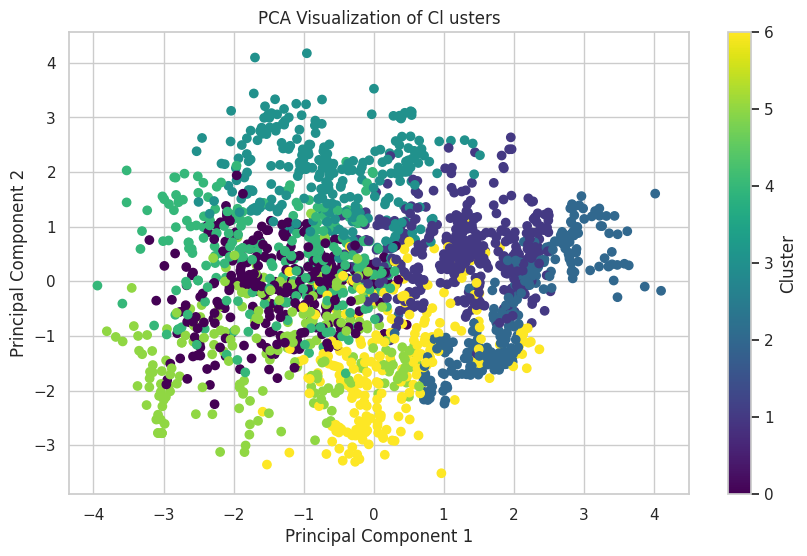

In [21]:
import pandas as pd

x_cluster = pd.concat([x_train, x_val, x_test])
print(x_cluster.shape)
y_cluster = pd.concat([y_train, y_val, y_test])

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertia = []
silhouette = []
k_range = range(2, 11)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init = 10)
    labels = kmeans.fit_predict(x_cluster)
    inertia.append(kmeans.inertia_)
    silhouette.append(silhouette_score(x_cluster, labels))

import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.plot(k_range, inertia, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(k_range, silhouette, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for Optimal k')
plt.tight_layout()
plt.show()

chosen_k = 7

kmeans = KMeans(n_clusters=chosen_k, random_state=RANDOM_STATE, n_init = 10)
labels = kmeans.fit_predict(x_cluster)
print(labels)

from sklearn.decomposition import PCA
pca = PCA(n_components=2, random_state = RANDOM_STATE)
x_cluster_pca = pca.fit_transform(x_cluster)

plt.figure(figsize=(10, 6))
plt.scatter(x_cluster_pca[:, 0], x_cluster_pca[:, 1], c=labels, cmap='viridis')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA Visualization of Cl usters')
plt.colorbar(label='Cluster')
plt.show()

In [22]:
obesity_full = pd.concat([y_train, y_val, y_test])

crosstab = pd.crosstab(obesity_full, labels)
crosstab.index = target_encoder.classes_
crosstab.columns = [f"Cluster {i}" for i in crosstab.columns]

print(crosstab)

                     Cluster 0  Cluster 1  Cluster 2  Cluster 3  Cluster 4  \
Insufficient_Weight         79          0          0         90         60   
Normal_Weight               98          3          0         66         64   
Obesity_Type_I              30        115          1         30         45   
Obesity_Type_II              2        202         13          0          0   
Obesity_Type_III             0          0        324          0          0   
Overweight_Level_I          52         17          0         55         56   
Overweight_Level_II         37         51          0         44         63   

                     Cluster 5  Cluster 6  
Insufficient_Weight         42          1  
Normal_Weight               47          9  
Obesity_Type_I              50         80  
Obesity_Type_II             28         52  
Obesity_Type_III             0          0  
Overweight_Level_I          64         46  
Overweight_Level_II         30         65  


**Clustering**

1. I chose k=7, supported by the elbow curve and the fact that the dataset has 7 obesity categories.
2. The clusters match the true obesity levels partially. Extreme obesity formed clearer clusters and neighboring categories overlapped.
3. When labels are unavailable, clusters could help identify groups with similar characteristics.

**REFLECTION**

1. The classifier learned from labelled obesity categorised and could predict them accurately. K-Means did not use labels but discovered natural groupings based on similarity in features.
2. Regression predicted a continuous value(tip_amount) and was evaluated using RMSE and R². Classification predicted categories of obesity and was evaluated using Accuracy, Macro-F1 and a confusion matrix.
3. The largest gap was in the RandomForestRegressor(Train(RFR): R² = 0.6694 and Test(RFR):R² = -0.1882). The most effective way to reduce overfitting was to limit model complexity through hyperparameter tuning.